In [1]:
!pip install -q git+https://github.com/probml/dynamax.git
import jax, jax.numpy as jnp
from jax.extend import backend as jax_backend
from jax import jit
import numpy as np, matplotlib.pyplot as plt, time
from flax import nnx
from tensorflow.keras.datasets import mnist
from scipy.ndimage import rotate
import optax
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time
import copy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


2025-11-29 20:15:29.432399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764447329.453545     812 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764447329.459864     812 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Device Setup
def setup_device():
    devices = jax.devices()
    backend = jax_backend.get_backend().platform
    print(f"Backend: {backend.upper()}")
    print(f"Devices: {len(devices)}")
    for i, device in enumerate(devices):
        print(f"  [{i}] {device.device_kind}: {device}")
    if backend == 'gpu':
        print(f"\n GPU acceleration enabled")
    elif backend == 'tpu':
        print(f"\n TPU acceleration enabled")
    else:
        print(f"\n CPU only")
    return devices[0], backend

device, backend = setup_device()

Backend: GPU
Devices: 1
  [0] Tesla P100-PCIE-16GB: cuda:0

 GPU acceleration enabled


In [3]:
# =====================================
# 2. Functional RNN with Classifier Head
# =====================================
import jax
import jax.numpy as jnp
from flax import nnx

# -------------------------
# RNN core (function-based)
# -------------------------
def rnn_forward(x, params, dropout, *, is_training=True):
    """
    Two-layer tanh RNN core.
    Args:
        x: (batch, seq, feat)
        params: dict containing linear modules
        dropout: nnx.Dropout module
        is_training: bool flag
    Returns:
        h2: final hidden state (batch, hidden_dim)
    """
    h1 = jnp.zeros((x.shape[0], params["Wxh1"].out_features))
    h2 = jnp.zeros_like(h1)

    for t in range(x.shape[1]):
        # First RNN layer
        h1 = jnp.tanh(params["Wxh1"](x[:, t, :]) + params["Whh1"](h1))
        if is_training:
            h1 = dropout(h1)
        
        # Second RNN layer
        h2 = jnp.tanh(params["Wxh2"](h1) + params["Whh2"](h2))
        if is_training:
            h2 = dropout(h2)

    return h2

# -------------------------
# Classifier head (small MLP + dropout)
# -------------------------
class RNNClassifierHead(nnx.Module):
    def __init__(self, in_dim: int, num_classes: int, dropout_rate=0.1, *, rngs: nnx.Rngs):
        hidden_dim = 120 #in_dim // 2  # small bottleneck
        self.fc1 = nnx.Linear(in_dim, hidden_dim, rngs=rngs)
        self.fc2 = nnx.Linear(hidden_dim, num_classes, rngs=rngs)
        self.dropout = nnx.Dropout(rate=dropout_rate, rngs=rngs)

    def __call__(self, features, *, is_training=True):
        x = jax.nn.relu(self.fc1(features))
        if is_training:
            x = self.dropout(x)
        return self.fc2(x)


# -------------------------
# Combined RNN model factory
# -------------------------
class TwoLayerRNNFunctional(nnx.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.1, *, rngs: nnx.Rngs):
        # Initialize RNN layers as dict
        self.params = {
            "Wxh1": nnx.Linear(input_dim, hidden_dim, rngs=rngs),
            "Whh1": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs),
            "Wxh2": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs),
            "Whh2": nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)
        }
        self.dropout = nnx.Dropout(dropout_rate, rngs=rngs)
        self.classifier = RNNClassifierHead(hidden_dim, num_classes, rngs=rngs)
        self.hidden_size = hidden_dim

    def __call__(self, x, *, is_training=True):
        features = rnn_forward(x, self.params, self.dropout, is_training=is_training)
        logits = self.classifier(features, is_training=is_training)
        return logits

    def extract_features(self, x):
        return rnn_forward(x, self.params, self.dropout, is_training=False)
        
# =====================================
# 3. Loss and Metric Utilities
# ====================================
@jit
def cross_entropy(logits, labels):
    y = jax.nn.one_hot(labels, 10)
    return -jnp.mean(jnp.sum(y * jax.nn.log_softmax(logits), axis=-1))

@jit
def accuracy(logits, labels):
    return jnp.mean(jnp.argmax(logits, -1) == labels)

Data loaded:
  Train: (10000, 28, 28), dtype=float32
  Test: (2000, 28, 28), dtype=float32
Train original: (10000, 28, 28), shifted: (10000, 28, 28)
Test  original: (2000, 28, 28),  shifted: (2000, 28, 28)
Applied domain shift: rotation=30°, contrast=1.8, brightness=0.4


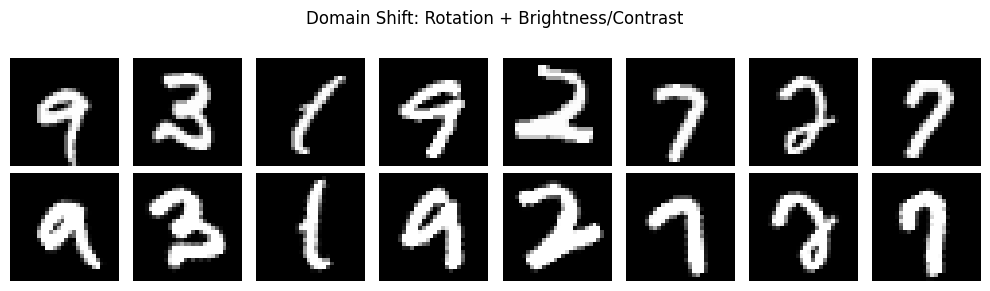

In [4]:
# =====================================
# 1. Setup and Data Preparation
# =====================================

# -------------------------
# Load MNIST
# -------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

# Reshape to (batch, seq, feat) = (N, 28, 28) for RNN input
X_train = X_train.reshape(-1, 28, 28)
X_test  = X_test.reshape(-1, 28, 28)

N_TRAIN = 10000
N_TEST = 2000
SEED = 42
rng = np.random.default_rng(SEED)

train_idx = rng.choice(len(X_train), N_TRAIN, replace=False)
test_idx  = rng.choice(len(X_test), N_TEST, replace=False)

X_train, y_train = X_train[train_idx], y_train[train_idx]
X_test,  y_test  = X_test[test_idx],  y_test[test_idx]

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test = jnp.array(X_test, dtype=jnp.float32)
y_train = jnp.array(y_train, dtype=jnp.int32)
y_test = jnp.array(y_test, dtype=jnp.int32)

print(f"Data loaded:")
print(f"  Train: {X_train.shape}, dtype={X_train.dtype}")
print(f"  Test: {X_test.shape}, dtype={X_test.dtype}")

# -------------------------
# Domain Shift Function
# -------------------------
def apply_domain_shift(
    X: np.ndarray,
    rotation_angle: float | None = None,
    contrast: float | None = None,
    brightness: float | None = None,
) -> np.ndarray:
    """
    Apply geometric (rotation) and photometric (brightness/contrast) shifts.
    - X: (N, 28, 28) images, values in [0,1]
    - rotation_angle: degrees, e.g., 15 or 30
    - contrast: multiplier (>1 = stronger contrast)
    - brightness: additive shift (>0 = brighter)
    """
    X_shifted = X.astype(np.float32).copy()

    # Rotation
    if rotation_angle is not None and rotation_angle != 0:
        X_shifted = np.array([
            rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
            for img in X_shifted
        ])

    # Brightness / contrast
    if contrast is not None or brightness is not None:
        c = contrast if contrast is not None else 1.0
        b = brightness if brightness is not None else 0.0
        X_shifted = np.clip(((X_shifted - 0.5) * c + 0.5) + b, 0, 1)

    return jnp.array(X_shifted, dtype=jnp.float32)

# -------------------------
# Define and apply the domain shift
# -------------------------
rotation_angle = 45      # degrees
contrast = 1.8
brightness = 0.4

X_train_shifted = apply_domain_shift(X_train, rotation_angle, contrast, brightness)
X_test_shifted  = apply_domain_shift(X_test,  rotation_angle, contrast, brightness)

y_train_shifted = y_train.copy()
y_test_shifted  = y_test.copy()

print(f"Train original: {X_train.shape}, shifted: {X_train_shifted.shape}")
print(f"Test  original: {X_test.shape},  shifted: {X_test_shifted.shape}")
print(f"Applied domain shift: rotation={rotation_angle}°, contrast={contrast}, brightness={brightness}")

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_test[i], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_test_shifted[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Shifted", rotation=0, labelpad=40)
plt.suptitle("Domain Shift: Rotation + Brightness/Contrast", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# =====================================
# 8. Online Fine-Tuning (True Online - Single Sample Updates)
# =====================================
print("\n" + "="*80)
print("ONLINE FINE-TUNING (True Online - Single Sample, Adam)")
print("="*80)

# ------------------------------------------------------------
# Create small subset: 2-3 samples per class
# ------------------------------------------------------------
def create_online_subset(X, y, samples_per_class, seed=42):
    """
    Create a small balanced subset for online learning.
    Args:
        X: data array (N, 28, 28)
        y: labels (N,)
        samples_per_class: number of samples per class
        seed: random seed
    Returns:
        X_subset, y_subset: small subset arrays
    """
    rng = np.random.default_rng(seed)
    subset_indices = []
    
    for class_id in range(10):
        class_indices = np.where(y == class_id)[0]
        selected = rng.choice(class_indices, size=samples_per_class, replace=False)
        subset_indices.extend(selected)
    
    subset_indices = np.array(subset_indices)
    rng.shuffle(subset_indices)  # Shuffle to mix classes
    
    return X[subset_indices], y[subset_indices]

# Create online training subset (3 samples per class = 30 total)
SAMPLES_PER_CLASS = 40
X_online_train, y_online_train = create_online_subset(
    X_train_shifted, y_train_shifted, 
    samples_per_class=SAMPLES_PER_CLASS, 
    seed=42
)

# Create online test subset (smaller test set for faster evaluation)
X_online_test, y_online_test = create_online_subset(
    X_test_shifted, y_test_shifted,
    samples_per_class=20,  # More test samples for reliable evaluation
    seed=43
    
)

print(f"Online training subset: {X_online_train.shape} ({SAMPLES_PER_CLASS} samples/class)")
print(f"Online test subset: {X_online_test.shape}")
print(f"Total training samples: {len(X_online_train)}")


ONLINE FINE-TUNING (True Online - Single Sample, Adam)
Online training subset: (400, 28, 28) (40 samples/class)
Online test subset: (200, 28, 28)
Total training samples: 400


In [6]:
def summarize_nnx_model(model):
    from jax.flatten_util import ravel_pytree
    print("\n==============================")
    print(" MODEL SUMMARY (NNX) ")
    print("==============================")

    total_params = 0
    # RNN core
    for name, layer in model.params.items():
        flat_params, _ = ravel_pytree(nnx.state(layer, nnx.Param))
        n = flat_params.size
        total_params += n
        print(f"{name:15s}: {layer.in_features} → {layer.out_features} ({n:,} params)")

    # Classifier
    for name, layer in vars(model.classifier).items():
        if isinstance(layer, nnx.Linear):
            flat_params, _ = ravel_pytree(nnx.state(layer, nnx.Param))
            n = flat_params.size
            total_params += n
            print(f"classifier.{name:7s}: {layer.in_features} → {layer.out_features} ({n:,} params)")

    print("-" * 50)
    print(f"Total parameters: {total_params:,}")
    print("==============================\n")
rngs = nnx.Rngs(0)
model = TwoLayerRNNFunctional(input_dim=28, hidden_dim=64, num_classes=10, rngs=rngs)
summarize_nnx_model(model)


 MODEL SUMMARY (NNX) 
Wxh1           : 28 → 64 (1,856 params)
Whh1           : 64 → 64 (4,160 params)
Wxh2           : 64 → 64 (4,160 params)
Whh2           : 64 → 64 (4,160 params)
classifier.fc1    : 64 → 120 (7,800 params)
classifier.fc2    : 120 → 10 (1,210 params)
--------------------------------------------------
Total parameters: 23,346



In [7]:
# =====================================
# 4. TrainState Utilities for RNN (NNX Compatible)
# =====================================
from flax.training import train_state
from typing import Any

class TrainStateFull(train_state.TrainState):
    graphdef: Any = None
    other_states: Any = None

class TrainStateOutputOnly(train_state.TrainState):
    full_graphdef: Any = None
    output_graphdef: Any = None
    full_other_states: Any = None
    output_other_states: Any = None


# -------------------------
# Full Model TrainState
# -------------------------
def create_train_state_full(model, learning_rate):
    """
    Create TrainState for full RNN pretraining.
    """
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)

    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, is_training=training)

    return TrainStateFull.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef,
        other_states=other_states
    )


# -------------------------
# Output Layer TrainState (Selective Adaptation)
# -------------------------
def create_train_state_output_only(model, learning_rate):
    """
    Create TrainState for fine-tuning only the classifier head (output layer).
    Keeps RNN core frozen and avoids stale dropout issues.
    """
    # Extract output (classifier) layer
    output_layer = model.classifier
    output_graphdef, output_params, output_other_states = nnx.split(output_layer, nnx.Param, ...)

    # Extract full model parts for feature extraction
    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)

    tx = optax.adam(learning_rate)

    def apply_fn(output_params, x, training=False):
        # Build frozen feature extractor
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        features = model_copy.extract_features(x)
        # Apply trainable head
        output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
        logits = output_layer_updated(features)
        return logits

    return TrainStateOutputOnly.create(
        apply_fn=apply_fn,
        params=output_params,
        tx=tx,
        full_graphdef=full_graphdef,
        output_graphdef=output_graphdef,
        full_other_states=full_other_states,
        output_other_states=output_other_states
    )


# -------------------------
# Output Layer TrainState (Selective Adaptation - fc2 only)
# -------------------------
def create_train_state_fc2_only(model, learning_rate):
    """
    Create TrainState for fine-tuning only fc2 (final linear layer).
    Keeps RNN core and fc1 frozen.
    """
    # Extract only fc2 layer
    fc2_layer = model.classifier.fc2
    fc2_graphdef, fc2_params, fc2_other_states = nnx.split(fc2_layer, nnx.Param, ...)
    
    # Extract full model parts for feature extraction
    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)
    
    tx = optax.adam(learning_rate)
    
    def apply_fn(fc2_params, x, training=False):
        # Build frozen model up to fc1
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        
        # Extract RNN features
        features = model_copy.extract_features(x)
        
        # Apply frozen fc1 + relu
        h = jax.nn.relu(model_copy.classifier.fc1(features))
        
        # Apply trainable fc2
        fc2_updated = nnx.merge(fc2_graphdef, fc2_params, fc2_other_states)
        logits = fc2_updated(h)
        
        return logits
    
    return TrainStateOutputOnly.create(
        apply_fn=apply_fn,
        params=fc2_params,
        tx=tx,
        full_graphdef=full_graphdef,
        output_graphdef=fc2_graphdef,
        full_other_states=full_other_states,
        output_other_states=fc2_other_states
    )

In [8]:
# =====================================
# 5. Training and Evaluation Steps
# =====================================


@jit
def pretrain_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=True)
        return cross_entropy(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = accuracy(logits, y)
    return state, loss, acc


@jit
def finetune_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=False)
        return cross_entropy(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = accuracy(logits, y)
    return state, loss, acc


@jit
def eval_step(state, batch):
    x, y = batch
    logits = state.apply_fn(state.params, x, training=False)
    loss = cross_entropy(logits, y)
    acc = accuracy(logits, y)
    return loss, acc

In [9]:
# =====================================
# 6. Baseline Pretraining (Two-Layer Functional RNN)
# =====================================

# Create train state for FULL model pretraining
state = create_train_state_full(model, learning_rate=1e-3)

epochs = 30
batch_size = 128
train_losses, train_accs, test_accs = [], [], []

print("\n==============================")
print(" Pretraining baseline RNN (TrainState version)")
print("==============================")

n_batches = int(np.ceil(len(X_train) / batch_size))

for ep in range(epochs):
    key = jax.random.PRNGKey(ep)
    perm = jax.random.permutation(key, len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss, epoch_acc = 0.0, 0.0

    # -----------------------------
    # Batch training loop
    # -----------------------------
    for i in range(n_batches):
        start, end = i * batch_size, min((i + 1) * batch_size, len(X_train))
        Xb, yb = X_shuf[start:end], y_shuf[start:end]
        state, loss, acc = pretrain_step(state, (Xb, yb))
        epoch_loss += float(loss)
        epoch_acc  += float(acc)

    epoch_loss /= n_batches
    epoch_acc  /= n_batches

    # -----------------------------
    # Evaluate on clean test set
    # -----------------------------
    test_loss, test_acc = eval_step(state, (X_test, y_test))
    test_loss, test_acc = float(test_loss), float(test_acc)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    test_accs.append(test_acc)

    print(f"Epoch {ep+1:2d}/{epochs}: "
          f"train_loss={epoch_loss:.4f} "
          f"train_acc={epoch_acc:.4f} "
          f"test_acc={test_acc:.4f}")

# ------------------------------------------------------------
# Save the trained model (for adaptation)
# ------------------------------------------------------------
graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
trained_model = nnx.merge(graphdef, state.params, other_states)

# ------------------------------------------------------------
# Evaluate baseline under domain shift
# ------------------------------------------------------------
print("\n==============================")
print(" Evaluating baseline under domain shift")
print("==============================")

shifted_loss, shifted_acc = eval_step(state, (X_test_shifted, y_test_shifted))
baseline_acc_shift = float(shifted_acc)

print(f"Baseline accuracy (clean test):   {test_accs[-1]:.4f}")
print(f"Baseline accuracy (shifted test): {baseline_acc_shift:.4f}")
print(f"Accuracy drop due to shift:      {(test_accs[-1] - baseline_acc_shift):.4f}")

# ------------------------------------------------------------
# Save baseline for adaptation steps (e.g., selective fine-tuning)
# ------------------------------------------------------------
print("\nSaving pretrained baseline for adaptation...")
graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
baseline_model = nnx.merge(graphdef, params, other_states)
print("Baseline model snapshot created.")


 Pretraining baseline RNN (TrainState version)
Epoch  1/30: train_loss=1.7005 train_acc=0.4370 test_acc=0.6010
Epoch  2/30: train_loss=1.1023 train_acc=0.6633 test_acc=0.6850
Epoch  3/30: train_loss=0.9035 train_acc=0.7413 test_acc=0.7625
Epoch  4/30: train_loss=0.7723 train_acc=0.7912 test_acc=0.8130
Epoch  5/30: train_loss=0.6917 train_acc=0.8287 test_acc=0.8395
Epoch  6/30: train_loss=0.6253 train_acc=0.8440 test_acc=0.8585
Epoch  7/30: train_loss=0.5710 train_acc=0.8651 test_acc=0.8770
Epoch  8/30: train_loss=0.5338 train_acc=0.8769 test_acc=0.8820
Epoch  9/30: train_loss=0.5022 train_acc=0.8847 test_acc=0.8915
Epoch 10/30: train_loss=0.4738 train_acc=0.8957 test_acc=0.8980
Epoch 11/30: train_loss=0.4497 train_acc=0.8992 test_acc=0.9015
Epoch 12/30: train_loss=0.4310 train_acc=0.9070 test_acc=0.8990
Epoch 13/30: train_loss=0.4111 train_acc=0.9096 test_acc=0.9040
Epoch 14/30: train_loss=0.4109 train_acc=0.9131 test_acc=0.8950
Epoch 15/30: train_loss=0.3896 train_acc=0.9128 test_acc

In [10]:
# =====================================
# 7. Online Fine-Tuning (fc2 Only, True Online)
# =====================================
print("\n" + "="*80)
print("ONLINE FINE-TUNING (fc2 Only, Adam - True Online)")
print("="*80)

# Clone baseline model to avoid overwriting pretrained weights
finetune_model = nnx.clone(baseline_model)

# Create train state for only the fc2
ft_state = create_train_state_fc2_only(finetune_model, learning_rate=1e-4)

# Verify trainable parameters
from jax.flatten_util import ravel_pytree
flat_params, _ = ravel_pytree(ft_state.params)
print(f"Trainable parameters (fc2 only): {flat_params.size}")
print(f"Expected: {model.classifier.fc2.in_features * model.classifier.fc2.out_features + model.classifier.fc2.out_features}")
# CHANGE 1: Remove epochs and batch_size, work with samples directly
ft_losses, ft_accs, ft_test_accs = [], [], []

# CHANGE 2: Use online subset instead of full shifted data
n_samples = len(X_online_train)  # Changed from n_batches
n_passes = 100  # Multiple passes through the small dataset

# CHANGE 3: Evaluate BEFORE training (initial performance)
initial_loss, initial_acc = eval_step(ft_state, (X_online_test, y_online_test))
ft_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")

print(f"\nOnline fine-tuning: {n_samples} samples/pass × {n_passes} passes = {n_samples * n_passes} total updates")

update_count = 0
start_time = time.time()

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 1000)
    perm = jax.random.permutation(key, n_samples)
    X_shuffled = X_online_train[perm]
    y_shuffled = y_online_train[perm]
    
    for sample_idx in range(n_samples):
        x_single = X_shuffled[sample_idx:sample_idx+1]
        y_single = y_shuffled[sample_idx:sample_idx+1]
        
        ft_state, loss, acc = finetune_step(ft_state, (x_single, y_single))
        
        ft_losses.append(float(loss))
        ft_accs.append(float(acc))

        if sample_idx == n_samples - 1:        
            test_loss, test_acc = eval_step(ft_state, (X_online_test, y_online_test))
            ft_test_accs.append(float(test_acc))
        
        update_count += 1

        if sample_idx == n_samples - 1 and ((pass_idx + 1) % 10 == 0 or pass_idx == n_passes - 1):
            print(f"Pass {pass_idx+1:2d}/{n_passes}, Sample {sample_idx+1:3d}/{n_samples} (Update {update_count:4d}): "
                  f"loss={loss:.4f} test_acc={float(test_acc):.4f}")


ft_time = time.time() - start_time

# ------------------------------------------------------------
# Final evaluation (UNCHANGED)
# ------------------------------------------------------------
final_loss, final_acc = eval_step(ft_state, (X_online_test, y_online_test))
final_loss, final_acc = float(final_loss), float(final_acc)

print(f"\nOnline fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - ft_test_accs[0]:.4f}")

# CHANGE 8: Store results with online-specific info
ft_results = {
    'method': 'adam_finetuning',
    'train_losses': ft_losses,
    'train_accs': ft_accs,
    'test_accs': ft_test_accs,
    'final_loss': final_loss,
    'final_acc': final_acc,
    'n_samples': n_samples,
    'n_passes': n_passes,  # ADD THIS
    'total_updates': update_count,  # ADD THIS
    'time': ft_time,
    'time_per_update': ft_time / update_count,  # CHANGE: divide by update_count instead of n_samples
    'model': finetune_model,
    'state': ft_state,
}
print(f"\nOnline fine-tuning completed in {ft_time:.2f}s. Final acc={final_acc:.4f}")
print(f"Total updates: {update_count}")
print(f"Time per update: {ft_time/update_count*1000:.2f}ms")


ONLINE FINE-TUNING (fc2 Only, Adam - True Online)
Trainable parameters (fc2 only): 1210
Expected: 1210
Initial test accuracy: 0.0200

Online fine-tuning: 400 samples/pass × 100 passes = 40000 total updates
Pass 10/100, Sample 400/400 (Update 4000): loss=1.8396 test_acc=0.2950
Pass 20/100, Sample 400/400 (Update 8000): loss=1.3318 test_acc=0.3700
Pass 30/100, Sample 400/400 (Update 12000): loss=1.4158 test_acc=0.3800
Pass 40/100, Sample 400/400 (Update 16000): loss=1.3945 test_acc=0.3900
Pass 50/100, Sample 400/400 (Update 20000): loss=1.0920 test_acc=0.3950
Pass 60/100, Sample 400/400 (Update 24000): loss=0.9669 test_acc=0.4100
Pass 70/100, Sample 400/400 (Update 28000): loss=0.7021 test_acc=0.4150
Pass 80/100, Sample 400/400 (Update 32000): loss=2.0254 test_acc=0.4200
Pass 90/100, Sample 400/400 (Update 36000): loss=1.0884 test_acc=0.4400
Pass 100/100, Sample 400/400 (Update 40000): loss=1.4349 test_acc=0.4450

Online fine-tuning final accuracy: 0.4450
Improvement from initial: 0.425

In [11]:
# =====================================
# 8. EKF Adaptation (Classifier Head Only)
# =====================================

print("\n" + "="*80)
print("EKF FINE-TUNING (fc2 Only)")
print("="*80)

# ------------------------------------------------------------
# Helper function for model evaluation
# ------------------------------------------------------------
def eval_model(model, X_batch, y_batch):
    """Evaluate model on a batch (avoids TrainState confusion)"""
    logits = model(X_batch, is_training=False)
    loss = cross_entropy(logits, y_batch)
    acc = accuracy(logits, y_batch)
    return loss, acc

# ------------------------------------------------------------
# Clone baseline and initialize
# ------------------------------------------------------------
ekf_model = nnx.clone(baseline_model)
fc2_layer = ekf_model.classifier.fc2  # Only fc2
fc2_state = nnx.state(fc2_layer, nnx.Param)  # Only fc2 state
flat_params, unflatten_fn = ravel_pytree(fc2_state)
dim = flat_params.size
print(f"fc2 layer parameters: {dim}")

# ------------------------------------------------------------
# EKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-6
obs_sigma = 1e-3
n_passes = 20  # Multiple passes through online data
eval_every = 1  # Evaluate after every batch (which is every pass)
mini_batch_size = n_samples  # Use all samples as one batch

Q = jnp.eye(dim,dtype=jnp.float32) * dyn_sigma
R = jnp.eye(10, dtype=jnp.float32) * obs_sigma

n_samples = len(X_online_train)
ekf_losses, ekf_train_accs, ekf_test_accs = [], [], []

# Evaluate BEFORE training
initial_loss, initial_acc = eval_model(ekf_model, X_online_test, y_online_test)
ekf_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")
print(f"\nEKF fine-tuning: 1 batch/pass × {n_passes} passes = {n_passes} total batch updates")
print(f"  (Batch size: {mini_batch_size} samples)")
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

def emission_cov_fn(w, x):
    """Measurement noise covariance."""
    probs = emission_mean_fn(w, x)
    return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)

# ------------------------------------------------------------
# Emission function with NNX state handling
# ------------------------------------------------------------
def emission_mean_fn(w, x):
    """
    Emission model returning probabilities (fc2 only).
    
    Args:
        w: flattened fc2 parameters only
        x: single sample (28, 28) from EKF - NO batch dimension
    Returns:
        probabilities (10,) for this single sample
    """
    # Unflatten fc2 parameters only
    fc2_params = unflatten_fn(w)
    
    # Access fc2 weights
    W2 = fc2_params["kernel"].value
    b2 = fc2_params["bias"].value
    
    # EKF passes x with shape (28, 28), but extract_features expects (batch, 28, 28)
    x_batched = jnp.expand_dims(x, axis=0)  # Shape: (1, 28, 28)
    
    # Extract RNN features
    features = ekf_model.extract_features(x_batched)
    features_squeezed = jnp.squeeze(features, axis=0)
    
    # Forward through FROZEN fc1
    h = jax.nn.relu(ekf_model.classifier.fc1(features_squeezed))
    
    # Forward through TRAINABLE fc2
    logits = jnp.dot(h, W2) + b2
    
    # Return probabilities 
    return jax.nn.softmax(logits)

# ------------------------------------------------------------
# Functional EKF update (batch as pseudo-sequence)
# ------------------------------------------------------------
def ekf_update(model, Xb, yb, P_prev=None, step=0):
    """
    Run EKF update on fc2 only.
    
    Args:
        model: TwoLayerRNNFunctional model
        Xb: batch of inputs (batch_size, 28, 28)
        yb: batch of labels (batch_size,)
        P_prev: previous covariance matrix (dim, dim) or None
        step: current step (for logging)
    
    Returns:
        model: updated model
        P_new: updated covariance matrix
    """
    fc2_layer = model.classifier.fc2  # Only fc2
    fc2_state = nnx.state(fc2_layer, nnx.Param)  # Only fc2 state
    flat_params, unflatten_fn_local = ravel_pytree(fc2_state)
    dim = flat_params.size

    # Initialize or use previous covariance
    if P_prev is None:
        w_mean = flat_params
        P = jnp.eye(dim, dtype=jnp.float32) * prior_var
        print(f"  [EKF] Initialized covariance P0 ({dim}×{dim})")
    else:
        w_mean = flat_params  # Use current params as mean
        P = P_prev  
    
    # Add small regularization for numerical stability
    P = P + jnp.eye(dim, dtype=jnp.float32) * 1e-8

    # Feature extraction (done once for the whole batch)
    y_onehot = jax.nn.one_hot(yb, 10)

    # Setup EKF parameters
    params = ParamsGGSSM(
        initial_mean=w_mean,
        initial_covariance=P,
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn,
    )

    # Run EKF filter (treats batch as sequence)
    # inputs=Xb passes each sample (28, 28) to emission_mean_fn
    posterior = conditional_moments_gaussian_filter(
        params, EKFIntegrals(), y_onehot, inputs=Xb
    )

    # Extract final posterior mean and covariance
    w_mean_new = posterior.filtered_means[-1]
    P_new = posterior.filtered_covariances[-1] + jnp.eye(dim, dtype=jnp.float32) * 1e-8
    
    # Unflatten and update fc2 only
    updated_fc2_params = unflatten_fn_local(w_mean_new)
    
    # Update only fc2
    nnx.update(fc2_layer, updated_fc2_params)

    return model, P_new

# ------------------------------------------------------------
# EKF Training Loop
# ------------------------------------------------------------
P_ekf = None
start_time = time.time()
update_count = 0

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 9999)
    perm = jax.random.permutation(key, n_samples)
    X_shuffled = X_online_train[perm]
    y_shuffled = y_online_train[perm]
    
    # Use ALL samples as one batch
    x_batch = X_shuffled  # All 100 samples
    y_batch = y_shuffled
    
    # Run EKF update on full batch
    ekf_model, P_ekf = ekf_update(
        ekf_model, x_batch, y_batch, P_prev=P_ekf, step=update_count
    )
    
    # Evaluate on batch (for logging)
    loss, acc = eval_model(ekf_model, x_batch, y_batch)
    ekf_losses.append(float(loss))
    ekf_train_accs.append(float(acc))
    
    # Evaluate on test set after each batch update
    test_loss, test_acc = eval_model(ekf_model, X_online_test, y_online_test)
    ekf_test_accs.append(float(test_acc))
    
    update_count += 1
    
    print(f"Pass {pass_idx+1:2d}/{n_passes} (Update {update_count:d}): "
          f"train_loss={float(loss):.4f} train_acc={float(acc):.4f} test_acc={float(test_acc):.4f}")

ekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation and Logging
# ------------------------------------------------------------
final_loss, final_acc = eval_model(ekf_model, X_online_test, y_online_test)
print(f"\nEKF fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - ekf_test_accs[0]:.4f}")

ekf_results = {
    "method": "ekf_finetuning",
    "train_losses": ekf_losses,
    "train_accs": ekf_train_accs,
    "test_accs": ekf_test_accs,
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "n_samples": n_samples,
    "n_passes": n_passes,
    "total_updates": update_count,
    "time": ekf_time,
    "time_per_update": ekf_time / update_count,
    "model": ekf_model,
    "covariance": P_ekf,
}

print(f"\nEKF fine-tuning completed in {ekf_time:.2f}s")
print(f"Total updates: {update_count}")
print(f"Time per update: {ekf_time/update_count*1000:.2f}ms")


EKF FINE-TUNING (fc2 Only)
fc2 layer parameters: 1210
Initial test accuracy: 0.0200

EKF fine-tuning: 1 batch/pass × 20 passes = 20 total batch updates
  (Batch size: 400 samples)
  [EKF] Initialized covariance P0 (1210×1210)
Pass  1/20 (Update 1): train_loss=1.4717 train_acc=0.5300 test_acc=0.4400
Pass  2/20 (Update 2): train_loss=1.2997 train_acc=0.5750 test_acc=0.4700
Pass  3/20 (Update 3): train_loss=1.1992 train_acc=0.6225 test_acc=0.5150
Pass  4/20 (Update 4): train_loss=1.1287 train_acc=0.6525 test_acc=0.5250
Pass  5/20 (Update 5): train_loss=1.0744 train_acc=0.6700 test_acc=0.5300
Pass  6/20 (Update 6): train_loss=1.0305 train_acc=0.6925 test_acc=0.5450
Pass  7/20 (Update 7): train_loss=0.9937 train_acc=0.7000 test_acc=0.5450
Pass  8/20 (Update 8): train_loss=0.9621 train_acc=0.7025 test_acc=0.5500
Pass  9/20 (Update 9): train_loss=0.9344 train_acc=0.7050 test_acc=0.5500
Pass 10/20 (Update 10): train_loss=0.9097 train_acc=0.7175 test_acc=0.5550
Pass 11/20 (Update 11): train_lo

In [12]:
# # =====================================
# # DEKF Adaptation (Classifier Head Only)
# # =====================================
# from jax.flatten_util import ravel_pytree
# from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
# from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
# import time

# print("\n" + "="*80)
# print("DEKF FINE-TUNING (fc2 kernel and bias separately)")
# print("="*80)

# # ------------------------------------------------------------
# # Clone baseline and initialize
# # ------------------------------------------------------------
# dekf_model = nnx.clone(baseline_model)

# fc2_state = nnx.state(dekf_model.classifier.fc2, nnx.Param)
# fc2_kernel_state = {"kernel": fc2_state["kernel"]}
# fc2_bias_state = {"bias": fc2_state["bias"]}

# fc2_kernel_flat, fc2_kernel_unflatten = ravel_pytree(fc2_kernel_state)
# fc2_bias_flat, fc2_bias_unflatten = ravel_pytree(fc2_bias_state)

# fc2_kernel_dim = fc2_kernel_flat.size
# fc2_bias_dim = fc2_bias_flat.size

# print(f"FC2 kernel parameters: {fc2_kernel_dim}")
# print(f"FC2 bias parameters: {fc2_bias_dim}")
# print(f"Total FC2 parameters: {fc2_kernel_dim + fc2_bias_dim}")

# n_samples = len(X_online_train)
# dekf_losses, dekf_train_accs, dekf_test_accs = [], [], []

# # Evaluate BEFORE training
# initial_loss, initial_acc = eval_model(dekf_model, X_online_test, y_online_test)
# dekf_test_accs.append(float(initial_acc))
# print(f"Initial test accuracy: {float(initial_acc):.4f}")
# print(f"\nDEKF fine-tuning: 1 batch/pass × {n_passes} passes = {n_passes} total batch updates")
# print(f"  (Batch size: {mini_batch_size} samples)")
# # ------------------------------------------------------------
# # DEKF hyperparameters
# # ------------------------------------------------------------
# prior_var = 0.1
# dyn_sigma = 1e-6
# obs_sigma = 1e-3
# n_passes = 10  # Match EKF for comparison
# eval_every = 10
# mini_batch_size = n_samples
# # ------------------------------------------------------------
# # Helper functions
# # ------------------------------------------------------------
# def f_fn(w, x):
#     """Static weights (no dynamics)."""
#     return w

# def eval_model(model, X_batch, y_batch):
#     """Evaluate model on a batch"""
#     logits = model(X_batch, is_training=False)
#     loss = cross_entropy(logits, y_batch)
#     acc = accuracy(logits, y_batch)
#     return loss, acc

# # ------------------------------------------------------------
# # DEKF update: fc2 kernel and bias separately:
# # ------------------------------------------------------------
# def dekf_update(model, Xb, yb, P_kernel_prev=None, P_bias_prev=None, step=0):
#     """
#     Run DEKF update: fc2 kernel first, then fc2 bias (sequentially).
    
#     Args:
#         model: TwoLayerRNNFunctional model
#         Xb: batch of inputs (batch_size, 28, 28)
#         yb: batch of labels (batch_size,)
#         P_kernel_prev: previous covariance for fc2 kernel or None
#         P_bias_prev: previous covariance for fc2 bias or None
#         step: current step
    
#     Returns:
#         model: updated model
#         P_kernel_new: updated fc2 kernel covariance
#         P_bias_new: updated fc2 bias covariance
#     """
#     fc2_layer = model.classifier.fc2
#     y_onehot = jax.nn.one_hot(yb, 10)
    
#     # ========================================
#     # Step 1: Update fc2 kernel (freeze bias)
#     # ========================================
    
#     # Get fc2 kernel parameters
#     fc2_state_temp = nnx.state(model.classifier.fc2, nnx.Param)
#     fc2_kernel_state = {"kernel": fc2_state_temp["kernel"]}
#     fc2_kernel_flat, fc2_kernel_unflatten = ravel_pytree(fc2_kernel_state)
#     fc2_kernel_dim = fc2_kernel_flat.size
    
#     # Initialize kernel covariance
#     if P_kernel_prev is None:
#         P_kernel = jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * prior_var
#         print(f"  [DEKF] Initialized fc2 kernel covariance: ({fc2_kernel_dim}×{fc2_kernel_dim})")
#     else:
#         P_kernel = P_kernel_prev + jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * 1e-8
    
#     # Emission function for kernel (bias frozen)
#     def emission_mean_fn_kernel(w_kernel, x):
#         """
#         Update fc2 kernel while keeping bias frozen.
#         """
#         # Unflatten kernel parameters
#         params_kernel = fc2_kernel_unflatten(w_kernel)
#         W2 = params_kernel["kernel"].value  # Access dict key first, then .value
        
#         # Get frozen bias
#         b2 = fc2_layer.bias.value
        
#         # Add batch dimension for extract_features
#         x_batched = jnp.expand_dims(x, axis=0)  # (1, 28, 28)
#         features = model.extract_features(x_batched)  # (1, hidden_dim)
#         features_squeezed = jnp.squeeze(features, axis=0)  # (hidden_dim,)
        
#         # Forward through FROZEN fc1
#         h = jax.nn.relu(model.classifier.fc1(features_squeezed))
        
#         # Forward through fc2 with updated kernel and frozen bias
#         logits = jnp.dot(h, W2) + b2
        
#         return jax.nn.softmax(logits)
    
#     def emission_cov_fn_kernel(w, x):
#         """Measurement noise for kernel update"""
#         probs = emission_mean_fn_kernel(w, x)
#         return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
#     # Setup EKF for kernel
#     Q_kernel = jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * dyn_sigma
    
#     params_kernel_ggssm = ParamsGGSSM(
#         initial_mean=fc2_kernel_flat,
#         initial_covariance=P_kernel,
#         dynamics_function=f_fn,
#         dynamics_covariance=Q_kernel,
#         emission_mean_function=emission_mean_fn_kernel,
#         emission_cov_function=emission_cov_fn_kernel,
#     )
    
#     # Run EKF for kernel
#     posterior_kernel = conditional_moments_gaussian_filter(
#         params_kernel_ggssm, EKFIntegrals(), y_onehot, inputs=Xb
#     )
    
#     kernel_mean_new = posterior_kernel.filtered_means[-1]
#     P_kernel_new = posterior_kernel.filtered_covariances[-1] + jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * 1e-8
    
#     # Update kernel in the model
#     updated_kernel_params = fc2_kernel_unflatten(kernel_mean_new)
#     nnx.update(fc2_layer, updated_kernel_params)  # Update fc2_layer, not fc2_layer.kernel
    
#     # ========================================
#     # Step 2: Update fc2 bias (with updated kernel)
#     # ========================================
    
#     # Get fc2 bias parameters
#     fc2_state_temp = nnx.state(model.classifier.fc2, nnx.Param)
#     fc2_bias_state = {"bias": fc2_state_temp["bias"]}
#     fc2_bias_flat, fc2_bias_unflatten = ravel_pytree(fc2_bias_state)
#     fc2_bias_dim = fc2_bias_flat.size
    
#     # Initialize bias covariance
#     if P_bias_prev is None:
#         P_bias = jnp.eye(fc2_bias_dim, dtype=jnp.float32) * prior_var * 0.1  # Smaller for bias
#         print(f"  [DEKF] Initialized fc2 bias covariance: ({fc2_bias_dim}×{fc2_bias_dim})")
#     else:
#         P_bias = P_bias_prev + jnp.eye(fc2_bias_dim, dtype=jnp.float32) * 1e-8
    
#     # Emission function for bias (kernel updated)
#     def emission_mean_fn_bias(w_bias, x):
#         """
#         Update fc2 bias with updated kernel.
#         """
#         # Unflatten bias parameters
#         params_bias = fc2_bias_unflatten(w_bias)
#         b2 = params_bias["bias"].value
        
#         # Get updated kernel
#         W2 = fc2_layer.kernel.value
        
#         # Add batch dimension for extract_features
#         x_batched = jnp.expand_dims(x, axis=0)  # (1, 28, 28)
#         features = model.extract_features(x_batched)  # (1, hidden_dim)
#         features_squeezed = jnp.squeeze(features, axis=0)  # (hidden_dim,)
        
#         # Forward through FROZEN fc1
#         h = jax.nn.relu(model.classifier.fc1(features_squeezed))
        
#         # Forward through fc2 with updated kernel and updated bias
#         logits = jnp.dot(h, W2) + b2
        
#         return jax.nn.softmax(logits)
    
#     def emission_cov_fn_bias(w, x):
#         """Measurement noise for bias update"""
#         probs = emission_mean_fn_bias(w, x)
#         return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
#     # Setup EKF for bias
#     Q_bias = jnp.eye(fc2_bias_dim, dtype=jnp.float32) * dyn_sigma * 0.1  # Smaller dynamics noise for bias
    
#     params_bias_ggssm = ParamsGGSSM(
#         initial_mean=fc2_bias_flat,
#         initial_covariance=P_bias,
#         dynamics_function=f_fn,
#         dynamics_covariance=Q_bias,
#         emission_mean_function=emission_mean_fn_bias,
#         emission_cov_function=emission_cov_fn_bias,
#     )
    
#     # Run EKF for bias
#     posterior_bias = conditional_moments_gaussian_filter(
#         params_bias_ggssm, EKFIntegrals(), y_onehot, inputs=Xb
#     )
    
#     bias_mean_new = posterior_bias.filtered_means[-1]
#     P_bias_new = posterior_bias.filtered_covariances[-1] + jnp.eye(fc2_bias_dim, dtype=jnp.float32) * 1e-8
    
#     # Update bias in the model
#     updated_bias_params = fc2_bias_unflatten(bias_mean_new)
#     nnx.update(fc2_layer, updated_bias_params)
    
#     return model, P_kernel_new, P_bias_new
# # ------------------------------------------------------------
# # DEKF Training Loop
# # ------------------------------------------------------------
# P_kernel = None
# P_bias = None
# start_time = time.time()
# update_count = 0

# for pass_idx in range(n_passes):
#     key = jax.random.PRNGKey(pass_idx + 9999)
#     perm = jax.random.permutation(key, n_samples)
#     X_shuffled = X_online_train[perm]
#     y_shuffled = y_online_train[perm]
    
#     # Use ALL samples as one batch
#     x_batch = X_shuffled  # All samples
#     y_batch = y_shuffled
    
#     # Run DEKF update on full batch
#     dekf_model, P_kernel, P_bias = dekf_update(
#         dekf_model, x_batch, y_batch, P_kernel_prev=P_kernel, P_bias_prev=P_bias, step=update_count
#     )

#     # ADD: Calculate and store traces
#     trace_kernel = float(jnp.trace(P_kernel))
#     trace_bias = float(jnp.trace(P_bias))
    
#     # Evaluate on batch (for logging)
#     loss, acc = eval_model(dekf_model, x_batch, y_batch)
#     dekf_losses.append(float(loss))
#     dekf_train_accs.append(float(acc))
    
#     # Evaluate on test set after each batch update
#     test_loss, test_acc = eval_model(dekf_model, X_online_test, y_online_test)
#     dekf_test_accs.append(float(test_acc))
    
#     update_count += 1
    
#     print(f"Pass {pass_idx+1:2d}/{n_passes} (Update {update_count:d}): "
#           f"train_loss={float(loss):.4f} train_acc={float(acc):.4f} test_acc={float(test_acc):.4f}")
#     print(f"  Tr(P_kernel)={trace_kernel:.2e}, Tr(P_bias)={trace_bias:.2e}")


# dekf_time = time.time() - start_time
# # ------------------------------------------------------------
# # Final Evaluation and Logging
# # ------------------------------------------------------------
# final_loss, final_acc = eval_model(dekf_model, X_online_test, y_online_test)
# print(f"\nDEKF fine-tuning final accuracy: {final_acc:.4f}")
# print(f"Improvement from initial: {final_acc - dekf_test_accs[0]:.4f}")

# dekf_results = {
#     "method": "dekf_finetuning",
#     "train_losses": dekf_losses,
#     "train_accs": dekf_train_accs,
#     "test_accs": dekf_test_accs,
#     "final_loss": float(final_loss),
#     "final_acc": float(final_acc),
#     "n_samples": n_samples,
#     "n_passes": n_passes,
#     "total_updates": update_count,
#     "time": dekf_time,
#     "time_per_update": dekf_time / update_count,
#     "model": dekf_model,
#     "covariances": {"kernel": P_kernel, "bias": P_bias},
# }

# print(f"\nDEKF fine-tuning completed in {dekf_time:.2f}s")
# print(f"Total updates: {update_count}")
# print(f"Time per update: {dekf_time/update_count*1000:.2f}ms")

In [13]:
# =====================================
# LoRA Fine-tuning (fc2 Only)
# =====================================
import time

print("\n" + "="*80)
print("LORA FINE-TUNING (fc2 Only)")
print("="*80)

# ------------------------------------------------------------
# LoRA Hyperparameters
# ------------------------------------------------------------
lora_rank = 6
lora_alpha = 16.0
lora_lr = 1e-3
n_passes = 30

# ------------------------------------------------------------
# Create LoRA layers for fc1 and fc2
# ------------------------------------------------------------
def create_lora_classifier(base_classifier, rank, alpha, rngs):
    """
    Replace fc2 with LoRA version
    
    Args:
        base_classifier: RNNClassifierHead with fc1 and fc2
        rank: LoRA rank
        alpha: LoRA alpha (scaling factor)
        rngs: Random number generators
    
    Returns:
        Modified classifier with LoRA layers
    """
    # Clone the base classifier
    lora_classifier = nnx.clone(base_classifier)
    
    # Replace fc2 with LoRA
    fc2_in = base_classifier.fc2.in_features
    fc2_out = base_classifier.fc2.out_features
    
    lora_fc2 = nnx.LoRALinear(
        in_features=fc2_in,
        out_features=fc2_out,
        lora_rank=rank,
        rngs=rngs
    )
    
    # Copy pretrained weights
    lora_fc2.kernel.value = base_classifier.fc2.kernel.value
    lora_fc2.bias.value = base_classifier.fc2.bias.value
    lora_fc2.lora_scale = alpha / rank
    
    lora_classifier.fc2 = lora_fc2
    
    print(f"  LoRA fc2: rank={rank}, alpha={alpha}, scale={alpha/rank:.4f}")
    
    return lora_classifier

# ------------------------------------------------------------
# Create LoRA model
# ------------------------------------------------------------
lora_rng = nnx.Rngs(42)
lora_model = nnx.clone(baseline_model)
lora_model.classifier = create_lora_classifier(
    baseline_model.classifier, lora_rank, lora_alpha, lora_rng
)

# ------------------------------------------------------------
# Filter for LoRA trainable parameters
# ------------------------------------------------------------
def is_lora_trainable(path, value):
    """Filter for LoRA-specific parameters (adapters + biases)"""
    path_str = '/'.join(str(p) for p in path)
    # Include LoRA adapters
    if 'lora' in path_str.lower():
        return True
    # Include biases in fc1 and fc2
    if 'fc2' in path_str and 'bias' in path_str:
        return True
    return False

# Split model into trainable and frozen parameters
graphdef, trainable_params, frozen_params = nnx.split(lora_model, is_lora_trainable, ...)

# Count parameters
def count_params(pytree):
    return sum(v.value.size if hasattr(v, 'value') else v.size
               for v in jax.tree.leaves(pytree))

all_state = nnx.state(lora_model, nnx.Param)
lora_count = count_params(trainable_params)
all_count = sum(v.size for v in jax.tree.leaves(all_state))

print(f"\nLoRA trainable params: {lora_count:,}")
print(f"Total model params: {all_count:,}")
print(f"LoRA efficiency: {100 * lora_count / all_count:.2f}%")

n_samples = len(X_online_train)
lora_losses, lora_train_accs, lora_test_accs = [], [], []

# Evaluate BEFORE training
initial_logits = lora_model(X_online_test, is_training=False)
initial_loss = cross_entropy(initial_logits, y_online_test)
initial_acc = accuracy(initial_logits, y_online_test)
lora_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")
print(f"\nLoRA fine-tuning: {n_samples} samples/pass × {n_passes} passes = {n_samples * n_passes} total updates")

# ------------------------------------------------------------
# LoRA Training Step (JIT-compiled)
# ------------------------------------------------------------
tx = optax.adam(lora_lr)
opt_state = tx.init(trainable_params)

@jit
def lora_train_step(graphdef, trainable_params, frozen_params, opt_state, batch):
    """Pure, JIT-compiled LoRA training step"""
    x, y = batch
    
    def loss_fn(current_trainable_params):
        model_temp = nnx.merge(graphdef, current_trainable_params, frozen_params)
        logits = model_temp(x, is_training=False)  # No dropout in base RNN
        return cross_entropy(logits, y)
    
    # Compute loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)
    
    # Update trainable params
    updates, new_opt_state = tx.update(grads, opt_state, trainable_params)
    new_trainable_params = optax.apply_updates(trainable_params, updates)
    
    # Compute accuracy
    model_acc = nnx.merge(graphdef, new_trainable_params, frozen_params)
    logits_acc = model_acc(x, is_training=False)
    acc = accuracy(logits_acc, y)
    
    return new_trainable_params, new_opt_state, loss, acc

print("\nJIT-compiled LoRA training step defined")

# ------------------------------------------------------------
# LoRA Training Loop
# ------------------------------------------------------------
start_time = time.time()
update_count = 0

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 42)
    perm = jax.random.permutation(key, n_samples)
    X_shuffled = X_online_train[perm]
    y_shuffled = y_online_train[perm]
    
    for sample_idx in range(n_samples):
        # Get single sample (add batch dimension)
        x_single = X_shuffled[sample_idx:sample_idx+1]
        y_single = y_shuffled[sample_idx:sample_idx+1]
        
        # Run LoRA update on single sample
        trainable_params, opt_state, loss, acc = lora_train_step(
            graphdef, trainable_params, frozen_params, opt_state, (x_single, y_single)
        )
        
        lora_losses.append(float(loss))
        lora_train_accs.append(float(acc))
        
        # Update model with current parameters for evaluation
        updated_state = nnx.State.merge(trainable_params, frozen_params)
        nnx.update(lora_model, updated_state)

        if sample_idx == n_samples - 1:
            # Evaluate on test set after each update
            test_logits = lora_model(X_online_test, is_training=False)
            test_acc = accuracy(test_logits, y_online_test)
            lora_test_accs.append(float(test_acc))
            
        update_count += 1
        
        # Print every 100 updates
        if update_count % 100 == 0 or (pass_idx == n_passes - 1 and sample_idx == n_samples - 1):
            print(f"Pass {pass_idx+1:2d}/{n_passes}, Sample {sample_idx+1:3d}/{n_samples} (Update {update_count:4d}): "
                  f"loss={float(loss):.4f} test_acc={float(test_acc):.4f}")
lora_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_logits = lora_model(X_online_test, is_training=False)
final_loss = cross_entropy(final_logits, y_online_test)
final_acc = accuracy(final_logits, y_online_test)

print(f"\nLoRA fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - lora_test_accs[0]:.4f}")

lora_results = {
    "method": "lora_finetuning",
    "train_losses": lora_losses,
    "train_accs": lora_train_accs,
    "test_accs": lora_test_accs,
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "n_samples": n_samples,
    "n_passes": n_passes,
    "total_updates": update_count,
    "time": lora_time,
    "time_per_update": lora_time / update_count,
    "model": lora_model,
}

print(f"\nLoRA fine-tuning completed in {lora_time:.2f}s")
print(f"Total updates: {update_count}")
print(f"Time per update: {lora_time/update_count*1000:.2f}ms")


LORA FINE-TUNING (fc2 Only)
  LoRA fc2: rank=6, alpha=16.0, scale=2.6667

LoRA trainable params: 790
Total model params: 24,126
LoRA efficiency: 3.27%
Initial test accuracy: 0.0200

LoRA fine-tuning: 400 samples/pass × 30 passes = 12000 total updates

JIT-compiled LoRA training step defined
Pass  1/30, Sample 100/400 (Update  100): loss=1.7833 test_acc=0.5850
Pass  1/30, Sample 200/400 (Update  200): loss=2.6829 test_acc=0.5850
Pass  1/30, Sample 300/400 (Update  300): loss=2.5223 test_acc=0.5850
Pass  1/30, Sample 400/400 (Update  400): loss=2.0867 test_acc=0.1500
Pass  2/30, Sample 100/400 (Update  500): loss=1.8720 test_acc=0.1500
Pass  2/30, Sample 200/400 (Update  600): loss=2.6011 test_acc=0.1500
Pass  2/30, Sample 300/400 (Update  700): loss=1.6916 test_acc=0.1500
Pass  2/30, Sample 400/400 (Update  800): loss=2.0581 test_acc=0.2900
Pass  3/30, Sample 100/400 (Update  900): loss=1.9474 test_acc=0.2900
Pass  3/30, Sample 200/400 (Update 1000): loss=1.6641 test_acc=0.2900
Pass  3

In [14]:
# =====================================
# LoRA-EKF Fine-tuning 
# =====================================
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import time

print("\n" + "="*80)
print("LORA-EKF FINE-TUNING (fc2 Only)")
print("="*80)

# ------------------------------------------------------------
# Create LoRA model (reuse from previous LoRA section)
# ------------------------------------------------------------
lora_ekf_rng = nnx.Rngs(100)
lora_ekf_model = nnx.clone(baseline_model)

# Fixed function call (all positional arguments)
lora_ekf_model.classifier = create_lora_classifier(
    baseline_model.classifier, 6, 16.0, lora_ekf_rng
)

print(f"LoRA-EKF model created")
# ------------------------------------------------------------
# LoRA-EKF hyperparameters
# ------------------------------------------------------------
prior_var = 0.1
dyn_sigma = 1e-4
obs_sigma = 1e-3
n_passes = 20 # Online passes
eval_every = 1  # Evaluate after each batch (each pass)
mini_batch_size = n_samples  # Use all samples as one batch

# ------------------------------------------------------------
# Pre-compute features
# ------------------------------------------------------------
print("\nPre-computing RNN features for LoRA-EKF...")

n_samples = len(X_online_train)
online_train_features = lora_ekf_model.extract_features(X_online_train)
online_test_features = lora_ekf_model.extract_features(X_online_test)
print(f"Train features: {online_train_features.shape}")
print(f"Test features: {online_train_features.shape}")

lora_ekf_losses, lora_ekf_train_accs, lora_ekf_test_accs = [], [], []

# Evaluate BEFORE training
initial_logits = lora_ekf_model.classifier(online_test_features, is_training=False)
initial_loss = cross_entropy(initial_logits, y_online_test)
initial_acc = accuracy(initial_logits, y_online_test)
lora_ekf_test_accs.append(float(initial_acc))
print(f"Initial test accuracy: {float(initial_acc):.4f}")
print(f"\nLoRA-EKF fine-tuning: 1 batch/pass × {n_passes} passes = {n_passes} total batch updates")
print(f"  (Batch size: {mini_batch_size} samples)")
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def f_fn(w, x):
    """Static weights (no dynamics)."""
    return w

# ------------------------------------------------------------
# LoRA-EKF update function
# ------------------------------------------------------------
def lora_ekf_update(model, features_batch, yb, P_prev=None, step=0):
    """
    Run EKF on LoRA parameters only (both fc1 and fc2).
    Base kernels remain frozen.
    
    """
    classifier = model.classifier
    
    # ========================================
    # Extract LoRA trainable parameters
    # ========================================
    
    # Get fc2 state
    fc2_state = nnx.state(classifier.fc2, nnx.Param)
    
    # Extract trainable parameters (LoRA + bias) from both layers
    trainable_dict = {}
    
    # fc2 LoRA and bias
    if 'lora' in fc2_state:
        trainable_dict['fc2_lora'] = fc2_state['lora']
    if 'bias' in fc2_state:
        trainable_dict['fc2_bias'] = fc2_state['bias']
    
    # Flatten trainable params
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size
    
    if step == 0:
        print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
        print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")
    
    # Store frozen kernels
    frozen_kernel_fc2 = fc2_state['kernel']
    
    # ========================================
    # Define emission function 
    # ========================================
    
    def emission_mean_fn(w, feature_vector):
        """
        Forward pass with fc2 LoRA parameters only.
        
        Args:
            w: flattened fc2 LoRA parameters
            feature_vector: pre-computed RNN features (hidden_dim,)
        Returns:
            probabilities (10,)
        """
        # Unflatten trainable params
        params = unflatten_fn(w)
        
        # Forward through fc1
        h = jax.nn.relu(classifier.fc1(feature_vector))
        
        # Reconstruct fc2 state: frozen kernel + trainable LoRA + bias
        fc2_temp_state = {'kernel': frozen_kernel_fc2}
        if 'fc2_lora' in params:
            fc2_temp_state['lora'] = params['fc2_lora']
        if 'fc2_bias' in params:
            fc2_temp_state['bias'] = params['fc2_bias']
        
        # Merge fc2
        fc2_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)
        fc2_temp = nnx.merge(fc2_graphdef, fc2_temp_state, fc2_other_states)
        
        # Forward through fc2
        logits = fc2_temp(h)
        
        return jax.nn.softmax(logits)
    
    def emission_cov_fn(w, feature_vector):
        probs = emission_mean_fn(w, feature_vector)
        return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
    # ========================================
    # Initialize covariance
    # ========================================
    
    if P_prev is None:
        initial_covariance = jnp.eye(state_dim, dtype=jnp.float32) * prior_var
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {prior_var} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_prev + jnp.eye(state_dim, dtype=jnp.float32) * 1e-8
    
    # ========================================
    # Setup and run EKF
    # ========================================
    
    Q = jnp.eye(state_dim, dtype=jnp.float32) * dyn_sigma
    
    params_ggssm = ParamsGGSSM(
        initial_mean=flat_params,
        initial_covariance=initial_covariance,
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn,
    )
    
    y_onehot = jax.nn.one_hot(yb, 10)
    
    # Run EKF filter
    posterior = conditional_moments_gaussian_filter(
        params_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
    )
    
    # Extract posterior
    updated_params_flat = posterior.filtered_means[-1]
    updated_covariance = posterior.filtered_covariances[-1] + jnp.eye(state_dim, dtype=jnp.float32) * 1e-8
    
    # ========================================
    # Update model with new parameters
    # ========================================
    
    updated_params = unflatten_fn(updated_params_flat)
    
    # Update fc2
    if 'fc2_lora' in updated_params or 'fc2_bias' in updated_params:
        fc2_update_dict = {}
        if 'fc2_lora' in updated_params:
            fc2_update_dict['lora'] = updated_params['fc2_lora']
        if 'fc2_bias' in updated_params:
            fc2_update_dict['bias'] = updated_params['fc2_bias']
        nnx.update(classifier.fc2, fc2_update_dict)
    
    return model, updated_covariance

# ------------------------------------------------------------
# LoRA-EKF Training Loop
# ------------------------------------------------------------
# REPLACE entire training loop (from "P_lora_ekf = None" to "lora_ekf_time = ...") with:
P_lora_ekf = None
start_time = time.time()
update_count = 0

for pass_idx in range(n_passes):
    key = jax.random.PRNGKey(pass_idx + 200)
    perm = jax.random.permutation(key, n_samples)
    features_shuffled = online_train_features[perm]
    y_shuffled = y_online_train[perm]
    
    # Use ALL samples as one batch
    features_batch = features_shuffled  # All features
    y_batch = y_shuffled
    
    # Run LoRA-EKF update on full batch
    lora_ekf_model, P_lora_ekf = lora_ekf_update(
        lora_ekf_model, features_batch, y_batch, P_prev=P_lora_ekf, step=update_count
    )
    
    # Evaluate on batch
    logits = lora_ekf_model.classifier(features_batch, is_training=False)
    loss = cross_entropy(logits, y_batch)
    acc = accuracy(logits, y_batch)
    lora_ekf_losses.append(float(loss))
    lora_ekf_train_accs.append(float(acc))
    
    # Evaluate on test set
    test_logits = lora_ekf_model.classifier(online_test_features, is_training=False)
    test_acc = accuracy(test_logits, y_online_test)
    lora_ekf_test_accs.append(float(test_acc))
    
    update_count += 1
    
    print(f"Pass {pass_idx+1:2d}/{n_passes} (Update {update_count:d}): "
          f"train_loss={float(loss):.4f} train_acc={float(acc):.4f} test_acc={float(test_acc):.4f}")

lora_ekf_time = time.time() - start_time

# ------------------------------------------------------------
# Final Evaluation
# ------------------------------------------------------------
final_logits = lora_ekf_model.classifier(online_test_features, is_training=False)
final_loss = cross_entropy(final_logits, y_online_test)
final_acc = accuracy(final_logits, y_online_test)

print(f"\nLoRA-EKF fine-tuning final accuracy: {final_acc:.4f}")
print(f"Improvement from initial: {final_acc - lora_ekf_test_accs[0]:.4f}")

lora_ekf_results = {
    "method": "lora_ekf_finetuning",
    "train_losses": lora_ekf_losses,
    "train_accs": lora_ekf_train_accs,
    "test_accs": lora_ekf_test_accs,
    "final_loss": float(final_loss),
    "final_acc": float(final_acc),
    "n_samples": n_samples,
    "n_passes": n_passes,
    "total_updates": update_count,
    "time": lora_ekf_time,
    "time_per_update": lora_ekf_time / update_count,
    "model": lora_ekf_model,
    "covariance": P_lora_ekf,
}

print(f"\nLoRA-EKF fine-tuning completed in {lora_ekf_time:.2f}s")
print(f"Total updates: {update_count}")
print(f"Time per update: {lora_ekf_time/update_count*1000:.2f}ms")


LORA-EKF FINE-TUNING (fc2 Only)
  LoRA fc2: rank=6, alpha=16.0, scale=2.6667
LoRA-EKF model created

Pre-computing RNN features for LoRA-EKF...
Train features: (400, 64)
Test features: (400, 64)
Initial test accuracy: 0.0200

LoRA-EKF fine-tuning: 1 batch/pass × 20 passes = 20 total batch updates
  (Batch size: 400 samples)
  [LoRA-EKF] Trainable params: 790 parameters
  [LoRA-EKF] Keys: ['fc2_lora', 'fc2_bias']
  [LoRA-EKF] Initializing covariance: P0 = 0.1 × I (790×790)
Pass  1/20 (Update 1): train_loss=1.5933 train_acc=0.4400 test_acc=0.4250
Pass  2/20 (Update 2): train_loss=1.2147 train_acc=0.5750 test_acc=0.4900
Pass  3/20 (Update 3): train_loss=1.0340 train_acc=0.6450 test_acc=0.5150
Pass  4/20 (Update 4): train_loss=0.8827 train_acc=0.6875 test_acc=0.5600
Pass  5/20 (Update 5): train_loss=0.7460 train_acc=0.7325 test_acc=0.5700
Pass  6/20 (Update 6): train_loss=0.6637 train_acc=0.7725 test_acc=0.5500
Pass  7/20 (Update 7): train_loss=0.5657 train_acc=0.8300 test_acc=0.5750
Pass

In [15]:
# # =====================================
# # LoRA-DEKF Fine-tuning
# # =====================================
# from jax.flatten_util import ravel_pytree
# from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
# from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
# import time

# print("\n" + "="*80)
# print("LORA-DEKF FINE-TUNING (fc2 LoRA kernel and bias separately)")
# print("="*80)

# # ------------------------------------------------------------
# # Create LoRA model
# # ------------------------------------------------------------
# lora_dekf_rng = nnx.Rngs(300)
# lora_dekf_model = nnx.clone(baseline_model)
# lora_dekf_model.classifier = create_lora_classifier(
#     baseline_model.classifier, 6, 16.0, lora_dekf_rng
# )

# print(f"LoRA-DEKF model created")

# # ------------------------------------------------------------
# # LoRA-DEKF hyperparameters
# # ------------------------------------------------------------
# prior_var = 0.1
# dyn_sigma = 1e-4
# obs_sigma = 1e-3
# n_passes = 20
# eval_every = 1  # Evaluate after each batch (each pass)
# mini_batch_size = n_samples  # Use all samples as one batch

# # ------------------------------------------------------------
# # Pre-compute features
# # ------------------------------------------------------------
# print("\nPre-computing RNN features for LoRA-DEKF...")

# n_samples = len(X_online_train)
# online_train_features = lora_dekf_model.extract_features(X_online_train)
# online_test_features = lora_dekf_model.extract_features(X_online_test)
# print(f"Train features: {online_train_features.shape}")
# print(f"Test features: {online_test_features.shape}")

# lora_dekf_losses, lora_dekf_train_accs, lora_dekf_test_accs = [], [], []

# # Evaluate BEFORE training
# initial_logits = lora_dekf_model.classifier(online_test_features, is_training=False)
# initial_loss = cross_entropy(initial_logits, y_online_test)
# initial_acc = accuracy(initial_logits, y_online_test)
# lora_dekf_test_accs.append(float(initial_acc))

# print(f"Initial test accuracy: {float(initial_acc):.4f}")
# print(f"\nLoRA-DEKF fine-tuning: 1 batch/pass × {n_passes} passes = {n_passes} total batch updates")
# print(f"  (Batch size: {mini_batch_size} samples)")
# # ------------------------------------------------------------
# # Helper functions
# # ------------------------------------------------------------
# def f_fn(w, x):
#     """Static weights (no dynamics)."""
#     return w

# # ------------------------------------------------------------
# # LoRA-DEKF update function (Sequential: fc1 → fc2)
# # ------------------------------------------------------------
# def lora_dekf_update(model, features_batch, yb, P_kernel_prev=None, P_bias_prev=None, step=0):
#     """
#     Run DEKF on fc2 LoRA parameters: update kernel first, then bias separately.
#     Base kernels remain frozen.
    
#     """
#     classifier = model.classifier
#     y_onehot = jax.nn.one_hot(yb, 10)

#     # ========================================
#     # Step 1: Update fc2 LoRA kernel (freeze bias)
#     # ========================================
    
#     # Get fc2 state
#     fc2_state = nnx.state(classifier.fc2, nnx.Param)
    
#     # Extract fc2 LoRA kernel only
#     fc2_kernel_trainable = {}
#     if 'lora' in fc2_state:
#         fc2_kernel_trainable['lora'] = fc2_state['lora']
    
#     # Flatten fc2 kernel trainable params
#     fc2_kernel_flat, fc2_kernel_unflatten = ravel_pytree(fc2_kernel_trainable)
#     fc2_kernel_dim = fc2_kernel_flat.size
    
#     if step == 0:
#         print(f"  [LoRA-DEKF] fc2 LoRA kernel trainable params: {fc2_kernel_dim}")
    
#     # Store frozen fc2 kernel and bias
#     frozen_kernel_fc2 = fc2_state['kernel']
#     frozen_bias_fc2 = fc2_state['bias']
    
#     # Initialize fc2 kernel covariance
#     if P_kernel_prev is None:
#         P_kernel = jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * prior_var
#         print(f"  [LoRA-DEKF] Initialized fc2 kernel covariance: ({fc2_kernel_dim}×{fc2_kernel_dim})")
#     else:
#         P_kernel = P_kernel_prev + jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * 1e-8
    
#     # Emission function for fc2 kernel (with frozen bias)
#     def emission_mean_fn_kernel(w_kernel, feature_vector):
#         """Update fc2 LoRA kernel while keeping bias frozen"""
#         # Unflatten kernel params
#         params_kernel = fc2_kernel_unflatten(w_kernel)
        
#         # Reconstruct fc2 state: frozen kernel + trainable LoRA + frozen bias
#         fc2_temp_state = {'kernel': frozen_kernel_fc2, 'bias': frozen_bias_fc2}
#         if 'lora' in params_kernel:
#             fc2_temp_state['lora'] = params_kernel['lora']
        
#         # Merge fc2
#         fc2_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)
#         fc2_temp = nnx.merge(fc2_graphdef, fc2_temp_state, fc2_other_states)
        
#         # Forward through FROZEN fc1
#         h = jax.nn.relu(classifier.fc1(feature_vector))
        
#         # Forward through fc2
#         logits = fc2_temp(h)
        
#         return jax.nn.softmax(logits)
    
#     def emission_cov_fn_kernel(w, x):
#         probs = emission_mean_fn_kernel(w, x)
#         return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
#     # Setup EKF for fc2 kernel
#     Q_kernel = jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * dyn_sigma
    
#     params_kernel_ggssm = ParamsGGSSM(
#         initial_mean=fc2_kernel_flat,
#         initial_covariance=P_kernel,
#         dynamics_function=f_fn,
#         dynamics_covariance=Q_kernel,
#         emission_mean_function=emission_mean_fn_kernel,
#         emission_cov_function=emission_cov_fn_kernel,
#     )
    
#     # Run EKF for fc2 kernel
#     posterior_kernel = conditional_moments_gaussian_filter(
#         params_kernel_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
#     )
    
#     kernel_mean_new = posterior_kernel.filtered_means[-1]
#     P_kernel_new = posterior_kernel.filtered_covariances[-1] + jnp.eye(fc2_kernel_dim, dtype=jnp.float32) * 1e-8
    
#     # Update fc2 kernel in the model
#     updated_kernel_params = fc2_kernel_unflatten(kernel_mean_new)
#     if 'lora' in updated_kernel_params:
#         nnx.update(classifier.fc2, {'lora': updated_kernel_params['lora']})

#     # ========================================
#     # Step 2: Update fc2 bias (with updated kernel)
#     # ========================================
    
#     # Get fc2 state (kernel is now updated)
#     fc2_state = nnx.state(classifier.fc2, nnx.Param)
    
#     # Extract fc2 bias only
#     fc2_bias_trainable = {}
#     if 'bias' in fc2_state:
#         fc2_bias_trainable['bias'] = fc2_state['bias']
    
#     # Flatten fc2 bias trainable params
#     fc2_bias_flat, fc2_bias_unflatten = ravel_pytree(fc2_bias_trainable)
#     fc2_bias_dim = fc2_bias_flat.size
    
#     if step == 0:
#         print(f"  [LoRA-DEKF] fc2 bias trainable params: {fc2_bias_dim}")
    
#     # Initialize fc2 bias covariance
#     if P_bias_prev is None:
#         P_bias = jnp.eye(fc2_bias_dim, dtype=jnp.float32) * prior_var * 0.1  # Smaller for bias
#         print(f"  [LoRA-DEKF] Initialized fc2 bias covariance: ({fc2_bias_dim}×{fc2_bias_dim})")
#     else:
#         P_bias = P_bias_prev + jnp.eye(fc2_bias_dim, dtype=jnp.float32) * 1e-8
    
#     # Emission function for fc2 bias (with updated kernel)
#     def emission_mean_fn_bias(w_bias, feature_vector):
#         """Update fc2 bias with updated LoRA kernel"""
#         # Unflatten bias params
#         params_bias = fc2_bias_unflatten(w_bias)
        
#         # Get current fc2 state (with updated LoRA)
#         fc2_current_state = nnx.state(classifier.fc2, nnx.Param)
        
#         # Reconstruct fc2 state: current kernel + LoRA + trainable bias
#         fc2_temp_state = {'kernel': fc2_current_state['kernel']}
#         if 'lora' in fc2_current_state:
#             fc2_temp_state['lora'] = fc2_current_state['lora']
#         if 'bias' in params_bias:
#             fc2_temp_state['bias'] = params_bias['bias']
        
#         # Merge fc2
#         fc2_graphdef, _, fc2_other_states = nnx.split(classifier.fc2, nnx.Param, ...)
#         fc2_temp = nnx.merge(fc2_graphdef, fc2_temp_state, fc2_other_states)
        
#         # Forward through FROZEN fc1
#         h = jax.nn.relu(classifier.fc1(feature_vector))
        
#         # Forward through fc2
#         logits = fc2_temp(h)
        
#         return jax.nn.softmax(logits)
    
#     def emission_cov_fn_bias(w, x):
#         probs = emission_mean_fn_bias(w, x)
#         return jnp.diag(probs * (1 - probs)) + obs_sigma * jnp.eye(10)
    
#     # Setup EKF for fc2 bias
#     Q_bias = jnp.eye(fc2_bias_dim, dtype=jnp.float32) * dyn_sigma * 0.1  # Smaller dynamics noise
    
#     params_bias_ggssm = ParamsGGSSM(
#         initial_mean=fc2_bias_flat,
#         initial_covariance=P_bias,
#         dynamics_function=f_fn,
#         dynamics_covariance=Q_bias,
#         emission_mean_function=emission_mean_fn_bias,
#         emission_cov_function=emission_cov_fn_bias,
#     )
    
#     # Run EKF for fc2 bias
#     posterior_bias = conditional_moments_gaussian_filter(
#         params_bias_ggssm, EKFIntegrals(), y_onehot, inputs=features_batch
#     )
    
#     bias_mean_new = posterior_bias.filtered_means[-1]
#     P_bias_new = posterior_bias.filtered_covariances[-1] + jnp.eye(fc2_bias_dim, dtype=jnp.float32) * 1e-8
    
#     # Update fc2 bias in the model
#     updated_bias_params = fc2_bias_unflatten(bias_mean_new)
#     if 'bias' in updated_bias_params:
#         nnx.update(classifier.fc2, {'bias': updated_bias_params['bias']})
    
#     return model, P_kernel_new, P_bias_new
        
# # ------------------------------------------------------------
# # LoRA-DEKF Training Loop
# # ------------------------------------------------------------
# P_kernel = None
# P_bias = None
# start_time = time.time()
# update_count = 0

# for pass_idx in range(n_passes):
#     key = jax.random.PRNGKey(pass_idx + 300)
#     perm = jax.random.permutation(key, n_samples)
#     features_shuffled = online_train_features[perm]
#     y_shuffled = y_online_train[perm]
    
#     # Use ALL samples as one batch
#     features_batch = features_shuffled  # All features
#     y_batch = y_shuffled
    
#     # Run LoRA-DEKF update on full batch
#     lora_dekf_model, P_kernel, P_bias = lora_dekf_update(
#         lora_dekf_model, features_batch, y_batch,
#         P_kernel_prev=P_kernel, P_bias_prev=P_bias, step=update_count
#     )
    
#     # Evaluate on batch
#     logits = lora_dekf_model.classifier(features_batch, is_training=False)
#     loss = cross_entropy(logits, y_batch)
#     acc = accuracy(logits, y_batch)
#     lora_dekf_losses.append(float(loss))
#     lora_dekf_train_accs.append(float(acc))
    
#     # Evaluate on test set
#     test_logits = lora_dekf_model.classifier(online_test_features, is_training=False)
#     test_acc = accuracy(test_logits, y_online_test)
#     lora_dekf_test_accs.append(float(test_acc))
    
#     update_count += 1
    
#     print(f"Pass {pass_idx+1:2d}/{n_passes} (Update {update_count:d}): "
#           f"train_loss={float(loss):.4f} train_acc={float(acc):.4f} test_acc={float(test_acc):.4f}")

# lora_dekf_time = time.time() - start_time

# # ------------------------------------------------------------
# # Final Evaluation
# # ------------------------------------------------------------
# final_logits = lora_dekf_model.classifier(online_test_features, is_training=False)
# final_loss = cross_entropy(final_logits, y_online_test)
# final_acc = accuracy(final_logits, y_online_test)

# print(f"\nLoRA-DEKF fine-tuning final accuracy: {final_acc:.4f}")
# print(f"Improvement from initial: {final_acc - lora_dekf_test_accs[0]:.4f}")

# lora_dekf_results = {
#     "method": "lora_dekf_finetuning",
#     "train_losses": lora_dekf_losses,
#     "train_accs": lora_dekf_train_accs,
#     "test_accs": lora_dekf_test_accs,
#     "final_loss": float(final_loss),
#     "final_acc": float(final_acc),
#     "n_samples": n_samples,
#     "n_passes": n_passes,
#     "total_updates": update_count,
#     "time": lora_dekf_time,
#     "time_per_update": lora_dekf_time / update_count,
#     "model": lora_dekf_model,
#     "covariances": {"kernel": P_kernel, "bias": P_bias},
# }

# print(f"\nLoRA-DEKF fine-tuning completed in {lora_dekf_time:.2f}s")
# print(f"Total updates: {update_count}")
# print(f"Time per update: {lora_dekf_time/update_count*1000:.2f}ms")

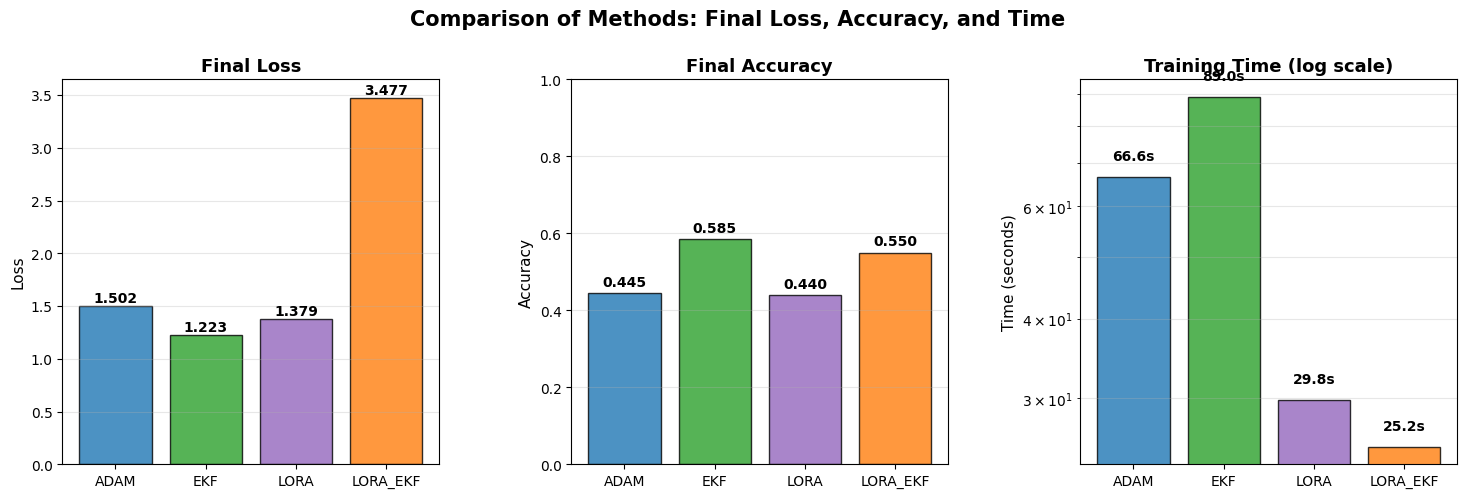

In [16]:
# ============================================================================
# SIMPLIFIED RESULTS VISUALIZATION (FINAL LOSS, ACCURACY, TIME)
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Use your actual experiment result variables
results = {
    'adam': ft_results,
    'ekf': ekf_results,
    #'dekf': dekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results,
    #'lora_dekf': lora_dekf_results
}

def plot_summary_results(results):
    """Plot bar charts for final loss, accuracy, and time across methods."""
    methods = list(results.keys())
    labels = [m.upper() for m in methods]

    # Extract metrics safely (handles missing keys)
    losses = [results[m].get('final_loss', np.nan) for m in methods]
    accs = [results[m].get('final_acc', np.nan) for m in methods]
    times = [results[m].get('time', np.nan) for m in methods]

    colors = ['#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.35)

    # -----------------------------
    # Plot 1: Final Loss
    # -----------------------------
    ax = axes[0]
    bars = ax.bar(labels, losses, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title("Final Loss", fontsize=13, fontweight='bold')
    ax.set_ylabel("Loss", fontsize=11)
    for i, v in enumerate(losses):
        ax.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # -----------------------------
    # Plot 2: Final Accuracy
    # -----------------------------
    ax = axes[1]
    bars = ax.bar(labels, accs, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title("Final Accuracy", fontsize=13, fontweight='bold')
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_ylim(0, 1)
    for i, v in enumerate(accs):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)

    # -----------------------------
    # Plot 3: Training Time
    # -----------------------------
    ax = axes[2]
    bars = ax.bar(labels, times, color=colors, alpha=0.8, edgecolor='black')
    ax.set_yscale('log')
    ax.set_title("Training Time (log scale)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Time (seconds)", fontsize=11)
    for i, v in enumerate(times):
        ax.text(i, v * 1.05, f"{v:.1f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', which='both', alpha=0.3)

    plt.suptitle("Comparison of Methods: Final Loss, Accuracy, and Time",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.show()

# Call the plotting function
plot_summary_results(results)